# Task: Covid-19 Data Analysis
### This notebook is used to understand the comprehension of Data Analysis techniques using Pandas library.

### Data Source: 
https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data/csse_covid_19_daily_reports

### File naming convention

MM-DD-YYYY.csv in UTC.

### Field description

- Province_State: China - province name; US/Canada/Australia/ - city name, state/province name; Others - name of the event (e.g., "Diamond Princess" cruise ship); other countries - blank.

- Country_Region: country/region name conforming to WHO (will be updated).

- Last_Update: MM/DD/YYYY HH:mm (24 hour format, in UTC).

- Confirmed: the number of confirmed cases. For Hubei Province: from Feb 13 (GMT +8), we report both clinically diagnosed and lab-confirmed cases. For lab-confirmed cases only (Before Feb 17), please refer to who_covid_19_situation_reports. For Italy, diagnosis standard might be changed since Feb 27 to "slow the growth of new case numbers." (Source)

- Deaths: the number of deaths.

- Recovered: the number of recovered cases.

In [26]:
import numpy as np
import pandas as pd

### Question 1

#### Read the dataset

In [27]:
df = pd.read_csv('07-24-2020.csv')
display(df)

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incidence_Rate,Case-Fatality_Ratio
0,45001.0,Abbeville,South Carolina,US,2020-07-25 04:47:39,34.223334,-82.461707,260,2,0,258,"Abbeville, South Carolina, US",1060.056265,0.769231
1,22001.0,Acadia,Louisiana,US,2020-07-25 04:47:39,30.295065,-92.414197,2111,62,0,2049,"Acadia, Louisiana, US",3402.369248,2.936997
2,51001.0,Accomack,Virginia,US,2020-07-25 04:47:39,37.767072,-75.632346,1059,15,0,1044,"Accomack, Virginia, US",3277.014482,1.416431
3,16001.0,Ada,Idaho,US,2020-07-25 04:47:39,43.452658,-116.241552,6732,45,0,6687,"Ada, Idaho, US",1397.878265,0.668449
4,19001.0,Adair,Iowa,US,2020-07-25 04:47:39,41.330756,-94.471059,20,0,0,20,"Adair, Iowa, US",279.642058,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3961,NaN,NaN,Unknown,Ukraine,2020-07-25 04:47:39,NaN,NaN,0,0,0,0,"Unknown, Ukraine",0.000000,0.000000
3962,NaN,NaN,NaN,Nauru,2020-07-25 04:47:39,-0.522800,166.931500,0,0,0,0,Nauru,0.000000,0.000000
3963,NaN,NaN,Niue,New Zealand,2020-07-25 04:47:39,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand",0.000000,0.000000
3964,NaN,NaN,NaN,Tuvalu,2020-07-25 04:47:39,-7.109500,177.649300,0,0,0,0,Tuvalu,0.000000,0.000000


#### Display the top 5 rows in the data

In [28]:
df.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incidence_Rate,Case-Fatality_Ratio
0,45001.0,Abbeville,South Carolina,US,2020-07-25 04:47:39,34.223334,-82.461707,260,2,0,258,"Abbeville, South Carolina, US",1060.056265,0.769231
1,22001.0,Acadia,Louisiana,US,2020-07-25 04:47:39,30.295065,-92.414197,2111,62,0,2049,"Acadia, Louisiana, US",3402.369248,2.936997
2,51001.0,Accomack,Virginia,US,2020-07-25 04:47:39,37.767072,-75.632346,1059,15,0,1044,"Accomack, Virginia, US",3277.014482,1.416431
3,16001.0,Ada,Idaho,US,2020-07-25 04:47:39,43.452658,-116.241552,6732,45,0,6687,"Ada, Idaho, US",1397.878265,0.668449
4,19001.0,Adair,Iowa,US,2020-07-25 04:47:39,41.330756,-94.471059,20,0,0,20,"Adair, Iowa, US",279.642058,0.000000


#### Show the information of the dataset

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3966 entries, 0 to 3965
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FIPS                 3237 non-null   float64
 1   Admin2               3242 non-null   str    
 2   Province_State       3790 non-null   str    
 3   Country_Region       3966 non-null   str    
 4   Last_Update          3966 non-null   str    
 5   Lat                  3884 non-null   float64
 6   Long_                3884 non-null   float64
 7   Confirmed            3966 non-null   int64  
 8   Deaths               3966 non-null   int64  
 9   Recovered            3966 non-null   int64  
 10  Active               3966 non-null   int64  
 11  Combined_Key         3966 non-null   str    
 12  Incidence_Rate       3884 non-null   float64
 13  Case-Fatality_Ratio  3903 non-null   float64
dtypes: float64(5), int64(4), str(5)
memory usage: 433.9 KB


#### Show the sum of missing values of features in the dataset

In [30]:
df.isna().sum()

FIPS                   729
Admin2                 724
Province_State         176
Country_Region           0
Last_Update              0
Lat                     82
Long_                   82
Confirmed                0
Deaths                   0
Recovered                0
Active                   0
Combined_Key             0
Incidence_Rate          82
Case-Fatality_Ratio     63
dtype: int64

### Question 2

#### Show the number of Confirmed cases by Country

In [31]:
df.groupby('Country_Region').agg({
    'Confirmed': 'sum'
}).reset_index()

,Country_Region,Confirmed
0,Afghanistan,36067
1,Albania,4570
2,Algeria,26159
3,Andorra,897
4,Angola,880
...,...,...
192,West Bank and Gaza,10093
193,Winter Olympics 2022,0
194,Yemen,1674
195,Zambia,3856


#### Show the number of Deaths by Country

In [32]:
df.groupby('Country_Region')['Deaths'].sum().reset_index()

,Country_Region,Deaths
0,Afghanistan,1229
1,Albania,128
2,Algeria,1136
3,Andorra,52
4,Angola,35
...,...,...
192,West Bank and Gaza,70
193,Winter Olympics 2022,0
194,Yemen,469
195,Zambia,136


#### Show the number of Recovered cases by Country

In [33]:
df.groupby('Country_Region')['Recovered'].agg('sum').reset_index()

,Country_Region,Recovered
0,Afghanistan,24602
1,Albania,2608
2,Algeria,17369
3,Andorra,803
4,Angola,241
...,...,...
192,West Bank and Gaza,2720
193,Winter Olympics 2022,0
194,Yemen,779
195,Zambia,1677


#### Show the number of Active Cases by Country

In [34]:
df.groupby('Country_Region')['Active'].sum().reset_index()

,Country_Region,Active
0,Afghanistan,10236
1,Albania,1834
2,Algeria,7654
3,Andorra,42
4,Angola,604
...,...,...
192,West Bank and Gaza,7303
193,Winter Olympics 2022,0
194,Yemen,426
195,Zambia,2043


#### Show the latest number of Confirmed, Deaths, Recovered and Active cases Country-wise

In [35]:
# First I convert the Last_Update field to timestamp so I can extract the maximum corresponding indexes
# country-wise
df['Last_Update']= pd.to_datetime(df['Last_Update'])
latest_indexes= df.groupby('Country_Region')['Last_Update'].idxmax()

# once with those indexes in hands I execute an "iloc" to locate the rows based on the extracted
# index Series
df.iloc[latest_indexes][['Country_Region', 'Confirmed', 'Deaths', 'Recovered', 'Active']]


,Country_Region,Confirmed,Deaths,Recovered,Active
3756,Afghanistan,36067,1229,24602,10236
3757,Albania,4570,128,2608,1834
3758,Algeria,26159,1136,17369,7654
3759,Andorra,897,52,803,42
3760,Angola,880,35,241,604
...,...,...,...,...,...
3919,West Bank and Gaza,10093,70,2720,7303
3956,Winter Olympics 2022,0,0,0,0
3920,Yemen,1674,469,779,426
3921,Zambia,3856,136,1677,2043


### Question 3

### Show the countries with no recovered cases

In [36]:
# extracting the total sum of recovered cases in a Series
total_recovered= df.groupby('Country_Region')['Recovered'].sum()

# displaying only the records which the total computed value is equal to zero
total_recovered[total_recovered == 0].reset_index()

,Country_Region,Recovered
0,Antarctica,0
1,Kiribati,0
2,"Korea, North",0
3,MS Zaandam,0
4,Nauru,0
5,Palau,0
6,Samoa,0
7,Serbia,0
8,Summer Olympics 2020,0
9,Sweden,0


#### Show the countries with no confirmed cases

In [37]:
# extracting the total sum of confirmed cases in a Series
total_confirmed= df.groupby('Country_Region')['Confirmed'].sum()

# displaying only the records which the total computed value is equal to zero
total_confirmed[total_confirmed == 0].reset_index()

,Country_Region,Confirmed
0,Antarctica,0
1,Kiribati,0
2,"Korea, North",0
3,Nauru,0
4,Palau,0
5,Samoa,0
6,Summer Olympics 2020,0
7,Tonga,0
8,Tuvalu,0
9,Winter Olympics 2022,0


#### Show the countries with no deaths

In [38]:
# extracting the total sum of deaths in a Series
total_deaths= df.groupby('Country_Region')['Deaths'].sum()

# displaying only the records which the total computed value is equal to zero
total_deaths[total_deaths == 0].reset_index()

,Country_Region,Deaths
0,Antarctica,0
1,Bhutan,0
2,Cambodia,0
3,Dominica,0
4,Eritrea,0
5,Fiji,0
6,Grenada,0
7,Holy See,0
8,Kiribati,0
9,"Korea, North",0


### Question 4

#### Show the Top 10 countries with Confirmed cases

In [39]:
df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered']]\
           .sum()\
           .sort_values(by=['Confirmed', 'Deaths', 'Recovered'] ,ascending=[False, False, False])\
           .head(10)

,Confirmed,Deaths,Recovered
Country_Region,,,
US,4115163,145444,1261624
Brazil,2351458,85437,1693214
India,1337024,31358,849432
Russia,799499,13026,587728
South Africa,421996,6343,245771
Mexico,378285,42645,283382
Peru,375961,51716,259423
Chile,341304,8914,313696
United Kingdom,299495,57259,1425


#### Show the Top 10 Countries with Active cases

In [40]:
df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']]\
           .sum()\
           .sort_values(
               by=['Confirmed', 'Deaths', 'Recovered', 'Active']
               ,ascending=[False, False, False, False])\
           .head(10)

,Confirmed,Deaths,Recovered,Active
Country_Region,,,,
US,4115163,145444,1261624,3981723
Brazil,2351458,85437,1693214,564914
India,1337024,31358,849432,456234
Russia,799499,13026,587728,198745
South Africa,421996,6343,245771,169882
Mexico,378285,42645,283382,52258
Peru,375961,51716,259423,324245
Chile,341304,8914,313696,18694
United Kingdom,299495,57259,1425,252313


### Question 5

#### Plot Country-wise Total deaths, confirmed, recovered and active casaes where total deaths have exceeded 50,000

In [41]:
import matplotlib.pyplot as plt

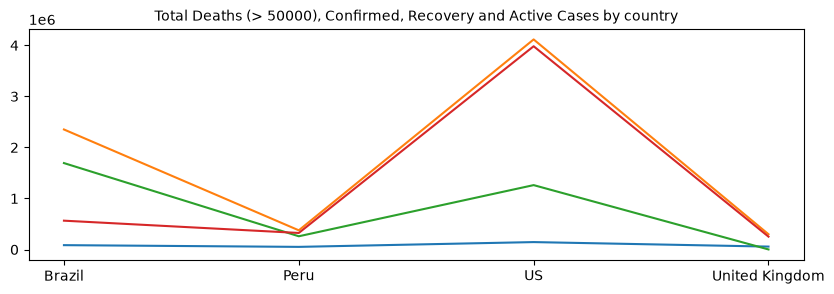

In [42]:
dg=df.groupby('Country_Region')[['Deaths','Confirmed','Recovered', 'Active']].sum()
dg= dg[
    dg['Deaths'] > 50000
]
dg= dg.reset_index()

plt.figure(figsize=(10,3))

plt.plot(dg['Country_Region'],dg['Deaths'])
plt.plot(dg['Country_Region'],dg['Confirmed'])
plt.plot(dg['Country_Region'],dg['Recovered'])
plt.plot(dg['Country_Region'],dg['Active'])
plt.title('Total Deaths (> 50000), Confirmed, Recovery and Active Cases by country', fontsize= 10)
plt.show()

### Question 6

### Plot Province/State wise Deaths in USA

In [43]:
import plotly.express as px

In [52]:
dg= df.groupby('Province_State')['Deaths'].sum().reset_index()

fig= px.bar(
    dg,
    x= 'Province_State',
    y= 'Deaths',
    title= 'State wise deaths reported of COVID-19 in USA',
    text_auto= True
)
fig.show()

### Question 7

### Plot Province/State Wise Active Cases in USA

In [50]:
dg= df.groupby('Province_State')['Active'].sum().reset_index()

fig= px.bar(
    dg,
    'Province_State',
    'Active',
    text_auto= True
)
fig.show()

### Question 8

### Plot Province/State Wise Confirmed cases in USA

In [59]:
dg= df.groupby('Province_State')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

fig= px.bar(
    dg,
    'Province_State',
    ['Confirmed', 'Deaths', 'Recovered', 'Active'],
    barmode= 'group',
    text_auto= True
)
fig.update_layout(legend_title_text='Case')
fig.show()

### Question 9

### Plot Worldwide Confirmed Cases over time

In [24]:
import plotly.express as px
import plotly.io as pio

In [ ]:
df.dtypes

FIPS                          float64
Admin2                            str
Province_State                    str
Country_Region                    str
Last_Update            datetime64[us]
Lat                           float64
Long_                         float64
Confirmed                       int64
Deaths                          int64
Recovered                       int64
Active                          int64
Combined_Key                      str
Incidence_Rate                float64
Case-Fatality_Ratio           float64
dtype: object

In [61]:
dg= df.groupby('Last_Update')['Confirmed'].sum().reset_index()

fig= px.line(
    dg,
    'Last_Update',
    'Confirmed',
)

fig.show()